In [12]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================

import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import deep_sdf.workspace as ws
import networks.sdf_vae as vae
import json
import time
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, SpectralEmbedding
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Set up paths for supervised model
experiment_directory = "examples/hippocampus_MS"  # Changed from hippocampus_healthy

# Load specs
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]

# Model parameters
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

print("="*60)
print("AGE-SUPERVISED HIPPOCAMPUS LATENT ANALYSIS")
print("="*60)
print(f"Latent size: {latent_size}")
print(f"Supervised dimension: z[1] (age)")
print(f"Other dimensions: z[0], z[2]...z[{latent_size-1}] (for disease analysis)")

AGE-SUPERVISED HIPPOCAMPUS LATENT ANALYSIS
Latent size: 16
Supervised dimension: z[1] (age)
Other dimensions: z[0], z[2]...z[15] (for disease analysis)


In [13]:
# ============================================================================
# CELL 2: MODEL LOADING AND LATENT EXTRACTION
# ============================================================================

def load_supervised_model_and_extract_latents():
    """Load supervised model and extract latent variables for all training data"""
    
    # Load supervised model from hippocampus_MS
    decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
    
    model_file = os.path.join(experiment_directory, "ModelParameters", "2000.pth")
    if os.path.exists(model_file):
        print(f"Loading supervised model from: {model_file}")
        saved_model_state = torch.load(model_file)
        decoder.load_state_dict(saved_model_state["model_state_dict"])
        decoder.eval()
        print("Supervised model loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file not found: {model_file}")
    
    # Load training data
    with open(train_split_file, "r") as f:
        train_split = json.load(f)
    
    # Get training filenames
    import deep_sdf.data as data
    eval_train_filenames = data.get_instance_filenames(data_source, train_split)
    
    # Load labels
    labels_path = os.path.join(data_source, "labels.pt")
    all_labels = torch.load(labels_path)
    
    # Extract latents for each training sample
    all_latents = []
    all_ages = []
    all_diseases = []
    filenames = []
    
    print(f"Extracting latents from {len(eval_train_filenames)} training samples...")
    
    with torch.no_grad():
        for i, train_fname in enumerate(eval_train_filenames):
            if i % 50 == 0:
                print(f"Processing {i}/{len(eval_train_filenames)}")
                
            save_name = os.path.basename(train_fname).split(".npz")[0]
            mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
            
            # Get surface points
            surface_points = data.get_surface_points(mesh_path)
            surface_points = torch.from_numpy(surface_points).unsqueeze(0).cuda()
            
            # Extract latent using encoder
            if kl_div_loss:
                mu, logvar = decoder.encoder(surface_points)
                latent = mu
            else:
                latent = decoder.encoder(surface_points)
            
            all_latents.append(latent.cpu().numpy().squeeze())
            
            # Get labels
            if save_name in all_labels:
                label = all_labels[save_name]
                all_ages.append(float(label[0].item()))
                all_diseases.append(int(label[1].item()))
            else:
                print(f"Warning: No label found for {save_name}")
                all_ages.append(0.0)
                all_diseases.append(0)
            
            filenames.append(save_name)
    
    latents_array = np.stack(all_latents, axis=0)
    print(f"Extracted latents shape: {latents_array.shape}")
    
    return {
        'latents': latents_array,
        'ages': np.array(all_ages),
        'diseases': np.array(all_diseases),
        'filenames': filenames,
        'decoder': decoder
    }

# Extract latents from supervised model
print("="*60)
print("EXTRACTING LATENTS FROM SUPERVISED MODEL")
print("="*60)

supervised_data = load_supervised_model_and_extract_latents()

# Save the extracted latents
save_dir = os.path.join(experiment_directory, "supervised_age_analysis")
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "supervised_latents.npy"), supervised_data['latents'])
np.save(os.path.join(save_dir, "ages.npy"), supervised_data['ages'])
np.save(os.path.join(save_dir, "diseases.npy"), supervised_data['diseases'])

print(f"Saved latents to: {save_dir}")
print(f"Supervised latents shape: {supervised_data['latents'].shape}")

EXTRACTING LATENTS FROM SUPERVISED MODEL
Loading supervised model from: examples/hippocampus_MS/ModelParameters/2000.pth
Supervised model loaded successfully!
Extracting latents from 196 training samples...
Processing 0/196
Processing 50/196
Processing 50/196
Processing 100/196
Processing 100/196
Processing 150/196
Processing 150/196
Extracted latents shape: (196, 16)
Saved latents to: examples/hippocampus_MS/supervised_age_analysis
Supervised latents shape: (196, 16)
Extracted latents shape: (196, 16)
Saved latents to: examples/hippocampus_MS/supervised_age_analysis
Supervised latents shape: (196, 16)


ANALYSIS OF SUPERVISED Z[1] FOR AGE
Data statistics:
  Supervised latents: (196, 16)
  Ages: (196,), range: [0.3, 0.8]
  Diseases: (196,), unique: [0 1]

Supervised dimension z[1] analysis:
  Age correlation: -0.8410
  Disease correlation: 0.0818
  |Age correlation|: 0.8410

Disentanglement Quality:
  ✅ Good disentanglement: High age correlation, low disease correlation

Age Disentanglement Metrics (Full Analysis):
  Best R²: z[1] = 0.7073 (r = -0.8410)
  Second best R²: z[14] = 0.1770 (r = -0.4207)
  SAP Score (age): 0.5303 [using R² as per literature]
  ✅ z[1] is the best age predictor as expected!

Disease Correlation Analysis (All Dimensions):
--------------------------------------------------
Disease correlation in non-supervised dimensions:
  z[0]: R² = 0.5271, r = -0.7260
  z[7]: R² = 0.0181, r = 0.1347
  z[10]: R² = 0.0146, r = -0.1208
  z[5]: R² = 0.0096, r = 0.0980
  z[14]: R² = 0.0083, r = 0.0911
  SAP Score (disease, excl. z[1]): 0.5090
  Top disease-correlated dims: z[0, 7

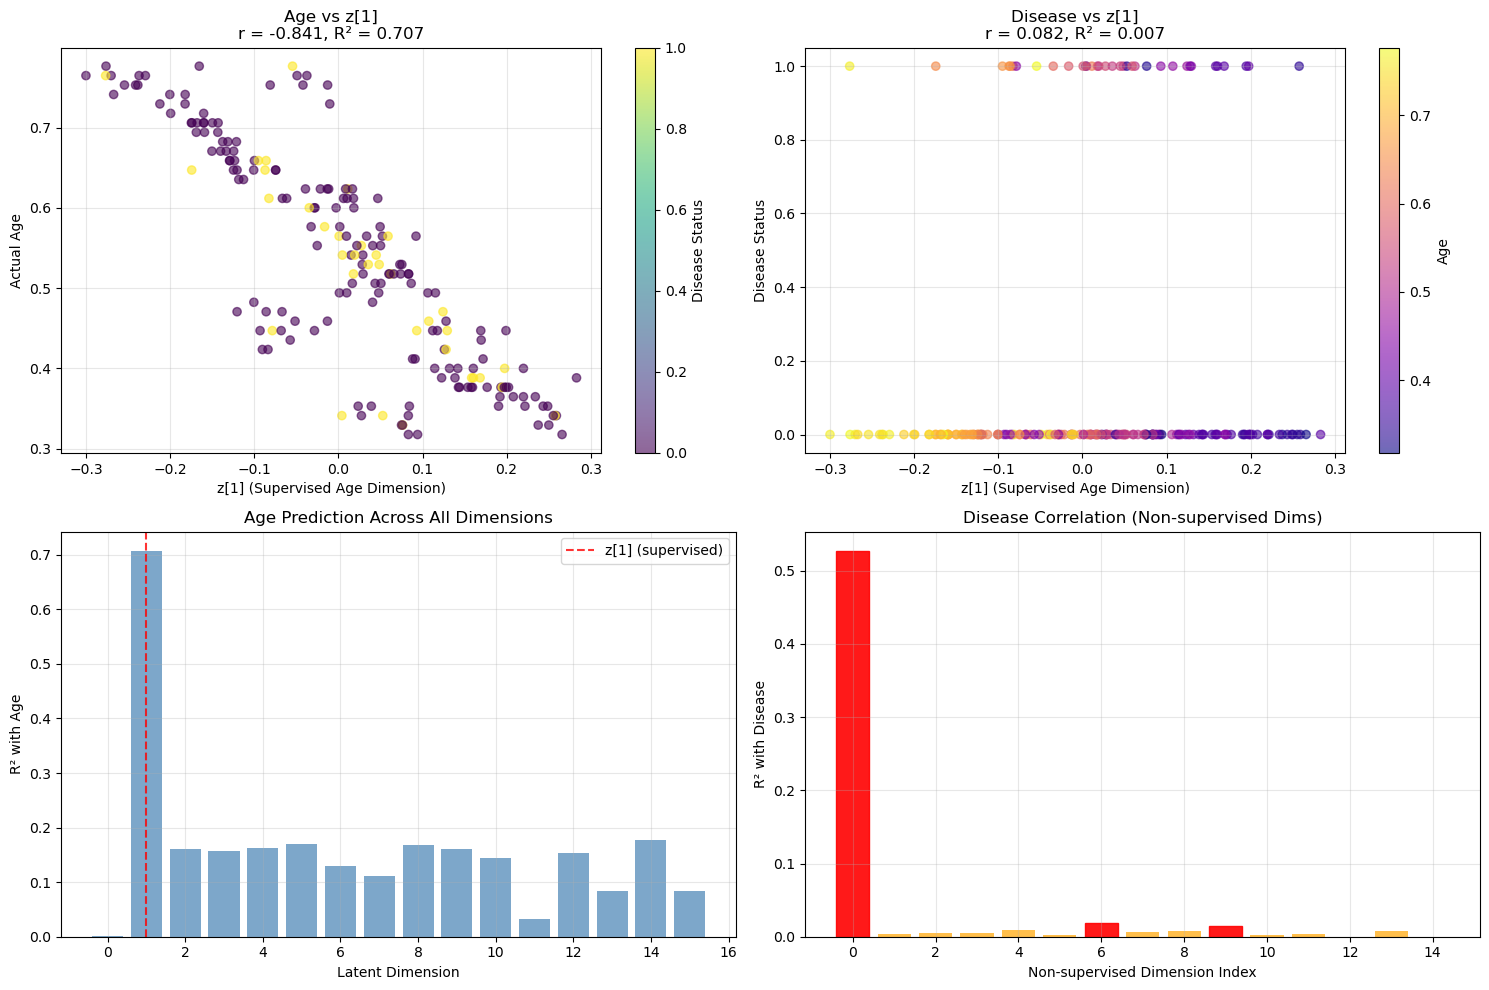


DETAILED CORRELATION ANALYSIS
Age Supervision Quality:
  z[1] → Age: r = -0.8410, R² = 0.7073
  z[1] → Disease: r = 0.0818, R² = 0.0067
  SAP Score (Age): 0.5303
  SAP Score (Disease, non-sup): 0.5090

Top Age-Predictive Dimensions:
  z[1]: R² = 0.7073
  z[14]: R² = 0.1770
  z[5]: R² = 0.1692

Top Disease-Predictive Dimensions (excluding z[1]):
  z[0]: R² = 0.5271
  z[7]: R² = 0.0181
  z[10]: R² = 0.0146


In [14]:
# ============================================================================
# CELL 3: ANALYSIS OF SUPERVISED Z[1] FOR AGE
# ============================================================================

# Get the data
Z_s = supervised_data['latents']  # Supervised latents (N, 16)
ages = supervised_data['ages']
diseases = supervised_data['diseases']

print("="*60)
print("ANALYSIS OF SUPERVISED Z[1] FOR AGE")
print("="*60)

# Basic statistics
print(f"Data statistics:")
print(f"  Supervised latents: {Z_s.shape}")
print(f"  Ages: {ages.shape}, range: [{ages.min():.1f}, {ages.max():.1f}]")
print(f"  Diseases: {diseases.shape}, unique: {np.unique(diseases)}")

# Focus on z[1] - the supervised age dimension
z1_age_correlation, _ = pearsonr(Z_s[:, 1], ages)
z1_disease_corr, _ = pearsonr(Z_s[:, 1], diseases)

print(f"\nSupervised dimension z[1] analysis:")
print(f"  Age correlation: {z1_age_correlation:.4f}")
print(f"  Disease correlation: {z1_disease_corr:.4f}")
print(f"  |Age correlation|: {abs(z1_age_correlation):.4f}")

# Check if z[1] is good age predictor and poor disease predictor
print(f"\nDisentanglement Quality:")
if abs(z1_age_correlation) > 0.5 and abs(z1_disease_corr) < 0.3:
    print(f"  ✅ Good disentanglement: High age correlation, low disease correlation")
elif abs(z1_age_correlation) > 0.5:
    print(f"  ⚠️ High age correlation but also correlates with disease")
else:
    print(f"  ❌ Poor age correlation - supervision may not be working well")

# Store for later analysis
age_corrs = np.zeros(Z_s.shape[1])  # Initialize for compatibility
age_corrs[1] = z1_age_correlation  # Only store z[1] correlation

# Calculate correlations and R² for all dimensions with age
age_corrs_all = np.zeros(Z_s.shape[1])
age_r2_all = np.zeros(Z_s.shape[1])

for i in range(Z_s.shape[1]):
    corr, _ = pearsonr(Z_s[:, i], ages)
    age_corrs_all[i] = corr
    age_r2_all[i] = corr ** 2  # R² = correlation²

# Calculate SAP score using R² (as per literature: "Disentangling by Factorising" - Higgins et al.)
# SAP measures how well the most informative latent variable predicts the attribute
# compared to the second most informative
sorted_r2_indices = np.argsort(age_r2_all)[::-1]  # descending order
sap_score_age = age_r2_all[sorted_r2_indices[0]] - age_r2_all[sorted_r2_indices[1]] if Z_s.shape[1] > 1 else age_r2_all[sorted_r2_indices[0]]

print(f"\nAge Disentanglement Metrics (Full Analysis):")
print(f"  Best R²: z[{sorted_r2_indices[0]}] = {age_r2_all[sorted_r2_indices[0]]:.4f} (r = {age_corrs_all[sorted_r2_indices[0]]:.4f})")
print(f"  Second best R²: z[{sorted_r2_indices[1]}] = {age_r2_all[sorted_r2_indices[1]]:.4f} (r = {age_corrs_all[sorted_r2_indices[1]]:.4f})")
print(f"  SAP Score (age): {sap_score_age:.4f} [using R² as per literature]")

# Check if z[1] is indeed the best age predictor
best_age_dim = sorted_r2_indices[0]
if best_age_dim == 1:
    print(f"  ✅ z[1] is the best age predictor as expected!")
else:
    print(f"  ⚠️  z[{best_age_dim}] is better than z[1] for age prediction")

# Disease correlation analysis for all dimensions
print(f"\nDisease Correlation Analysis (All Dimensions):")
print("-" * 50)
disease_corrs_all = np.zeros(Z_s.shape[1])
disease_r2_all = np.zeros(Z_s.shape[1])

for i in range(Z_s.shape[1]):
    corr, _ = pearsonr(Z_s[:, i], diseases)
    disease_corrs_all[i] = corr
    disease_r2_all[i] = corr ** 2

# Find dimensions most correlated with disease (excluding z[1])
non_supervised_dims = [i for i in range(Z_s.shape[1]) if i != 1]
disease_r2_others = disease_r2_all[non_supervised_dims]
sorted_disease_indices = np.argsort(disease_r2_others)[::-1]  # descending

print(f"Disease correlation in non-supervised dimensions:")
for i in range(min(5, len(sorted_disease_indices))):  # Top 5
    dim_idx = non_supervised_dims[sorted_disease_indices[i]]
    print(f"  z[{dim_idx}]: R² = {disease_r2_all[dim_idx]:.4f}, r = {disease_corrs_all[dim_idx]:.4f}")

# Calculate SAP score for disease (excluding z[1])
sap_score_disease = disease_r2_others[sorted_disease_indices[0]] - disease_r2_others[sorted_disease_indices[1]] if len(sorted_disease_indices) > 1 else disease_r2_others[sorted_disease_indices[0]]
print(f"  SAP Score (disease, excl. z[1]): {sap_score_disease:.4f}")

# Store best disease-correlated dimensions for later analysis
best_disease_dims = [non_supervised_dims[i] for i in sorted_disease_indices[:3]]  # Top 3
print(f"  Top disease-correlated dims: z{best_disease_dims}")

# Visualize age vs z[1] and disease correlation analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age vs z[1] scatter plot
scatter1 = axes[0, 0].scatter(Z_s[:, 1], ages, alpha=0.6, c=diseases, cmap='viridis')
axes[0, 0].set_xlabel('z[1] (Supervised Age Dimension)')
axes[0, 0].set_ylabel('Actual Age')
axes[0, 0].set_title(f'Age vs z[1]\nr = {z1_age_correlation:.3f}, R² = {z1_age_correlation**2:.3f}')
axes[0, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
cbar1.set_label('Disease Status')

# Disease vs z[1] scatter plot to show separation
scatter2 = axes[0, 1].scatter(Z_s[:, 1], diseases, alpha=0.6, c=ages, cmap='plasma')
axes[0, 1].set_xlabel('z[1] (Supervised Age Dimension)')
axes[0, 1].set_ylabel('Disease Status')  
axes[0, 1].set_title(f'Disease vs z[1]\nr = {z1_disease_corr:.3f}, R² = {z1_disease_corr**2:.3f}')
axes[0, 1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[0, 1])
cbar2.set_label('Age')

# Age R² across all dimensions
axes[1, 0].bar(range(len(age_r2_all)), age_r2_all, alpha=0.7, color='steelblue')
axes[1, 0].axvline(x=1, color='red', linestyle='--', alpha=0.8, label='z[1] (supervised)')
axes[1, 0].set_xlabel('Latent Dimension')
axes[1, 0].set_ylabel('R² with Age')
axes[1, 0].set_title('Age Prediction Across All Dimensions')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Disease R² for non-supervised dimensions
non_sup_dims = [i for i in range(len(disease_r2_all)) if i != 1]
non_sup_r2 = [disease_r2_all[i] for i in non_sup_dims]
bars = axes[1, 1].bar(range(len(non_sup_r2)), non_sup_r2, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Non-supervised Dimension Index')
axes[1, 1].set_ylabel('R² with Disease')
axes[1, 1].set_title('Disease Correlation (Non-supervised Dims)')
axes[1, 1].grid(True, alpha=0.3)

# Highlight top 3 disease-correlated dimensions
if len(non_sup_r2) >= 3:
    top_3_indices = np.argsort(non_sup_r2)[-3:]
    for idx in top_3_indices:
        bars[idx].set_color('red')
        bars[idx].set_alpha(0.9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "comprehensive_correlation_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

# Print detailed correlation analysis
print(f"\n" + "="*60)
print("DETAILED CORRELATION ANALYSIS")
print("="*60)
print(f"Age Supervision Quality:")
print(f"  z[1] → Age: r = {z1_age_correlation:.4f}, R² = {z1_age_correlation**2:.4f}")
print(f"  z[1] → Disease: r = {z1_disease_corr:.4f}, R² = {z1_disease_corr**2:.4f}")
print(f"  SAP Score (Age): {sap_score_age:.4f}")
print(f"  SAP Score (Disease, non-sup): {sap_score_disease:.4f}")

print(f"\nTop Age-Predictive Dimensions:")
for i in range(min(3, len(sorted_r2_indices))):
    dim = sorted_r2_indices[i]
    print(f"  z[{dim}]: R² = {age_r2_all[dim]:.4f}")

print(f"\nTop Disease-Predictive Dimensions (excluding z[1]):")
for i in range(min(3, len(best_disease_dims))):
    dim = best_disease_dims[i]
    print(f"  z[{dim}]: R² = {disease_r2_all[dim]:.4f}")

In [15]:
# ============================================================================
# COMPREHENSIVE DISENTANGLEMENT ANALYSIS FOR BOTH TRAIN AND TEST DATA
# ============================================================================

print("="*80)
print("COMPREHENSIVE DISENTANGLEMENT ANALYSIS: z[0]↔Disease, z[1]↔Age")
print("="*80)

import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def calculate_sap_score_comprehensive(Z, labels_cls, labels_reg, target_dim_cls=0, target_dim_reg=1):
    """
    Calculate SAP (Separated Attribute Predictability) score for disentanglement
    According to Kumar et al. (2018) "Variational Inference of Disentangled Representations"
    
    SAP Score = E_k[max_j R²(k,j) - (1/(D-1)) * sum_{j≠j_max} R²(k,j)]
    where:
    - k indexes factors (attributes like age, disease)  
    - j indexes latent dimensions
    - R²(k,j) is the coefficient of determination between factor k and dimension j
    
    For classification, we use R² from logistic regression instead of accuracy
    
    Args:
        Z: Latent representations (N, D)
        labels_cls: Classification labels (disease) (N,)
        labels_reg: Regression labels (age) (N,)
        target_dim_cls: Target dimension for classification (default: 0)
        target_dim_reg: Target dimension for regression (default: 1)
    
    Returns:
        Dictionary with SAP scores and detailed metrics
    """
    from sklearn.linear_model import LinearRegression, LogisticRegression
    from sklearn.metrics import r2_score
    
    N, D = Z.shape
    
    # Calculate R² scores for each dimension predicting each factor
    # Factor 1: Age (continuous regression)
    age_r2_scores = []
    for d in range(D):
        z_d = Z[:, d].reshape(-1, 1)
        try:
            lr = LinearRegression()
            lr.fit(z_d, labels_reg)
            age_pred = lr.predict(z_d)
            r2 = r2_score(labels_reg, age_pred)
            # Ensure R² is non-negative (can be negative for very bad fits)
            r2 = max(0, r2)
        except:
            r2 = 0.0
        age_r2_scores.append(r2)
    
    # Factor 2: Disease (binary classification - use pseudo R² from logistic regression)
    disease_r2_scores = []
    for d in range(D):
        z_d = Z[:, d].reshape(-1, 1)
        try:
            # Use logistic regression and calculate McFadden's pseudo R²
            lr = LogisticRegression(random_state=42, max_iter=1000)
            lr.fit(z_d, labels_cls)
            
            # Calculate log-likelihood of fitted model
            log_prob = lr.predict_log_proba(z_d)
            ll_model = np.sum(log_prob[np.arange(len(labels_cls)), labels_cls])
            
            # Calculate log-likelihood of null model (intercept only)
            p_pos = np.mean(labels_cls)
            p_neg = 1 - p_pos
            ll_null = len(labels_cls) * (p_pos * np.log(p_pos + 1e-10) + p_neg * np.log(p_neg + 1e-10))
            
            # McFadden's pseudo R² = 1 - (LL_model / LL_null)
            pseudo_r2 = 1 - (ll_model / ll_null) if ll_null != 0 else 0
            pseudo_r2 = max(0, pseudo_r2)  # Ensure non-negative
            
        except:
            pseudo_r2 = 0.0
            
        disease_r2_scores.append(pseudo_r2)
    
    # Convert to numpy arrays
    age_r2_scores = np.array(age_r2_scores)
    disease_r2_scores = np.array(disease_r2_scores)
    
    # Calculate SAP scores according to literature
    # SAP_age = max_j R²(age,j) - (1/(D-1)) * sum_{j≠j_max} R²(age,j)
    age_max_idx = np.argmax(age_r2_scores)
    age_max_r2 = age_r2_scores[age_max_idx]
    age_other_r2 = np.concatenate([age_r2_scores[:age_max_idx], age_r2_scores[age_max_idx+1:]])
    age_mean_other = np.mean(age_other_r2) if len(age_other_r2) > 0 else 0
    sap_age = age_max_r2 - age_mean_other
    
    # SAP_disease = max_j R²(disease,j) - (1/(D-1)) * sum_{j≠j_max} R²(disease,j)  
    disease_max_idx = np.argmax(disease_r2_scores)
    disease_max_r2 = disease_r2_scores[disease_max_idx]
    disease_other_r2 = np.concatenate([disease_r2_scores[:disease_max_idx], disease_r2_scores[disease_max_idx+1:]])
    disease_mean_other = np.mean(disease_other_r2) if len(disease_other_r2) > 0 else 0
    sap_disease = disease_max_r2 - disease_mean_other
    
    # Overall SAP score (average across factors)
    sap_overall = (sap_age + sap_disease) / 2
    
    # Additional metrics for analysis
    age_best_dim = age_max_idx
    disease_best_dim = disease_max_idx
    
    return {
        'sap_age': sap_age,
        'sap_disease': sap_disease, 
        'sap_overall': sap_overall,
        'age_r2_scores': age_r2_scores,
        'disease_r2_scores': disease_r2_scores,
        'age_best_dim': age_best_dim,
        'disease_best_dim': disease_best_dim,
        'age_target_is_best': age_best_dim == target_dim_reg,
        'disease_target_is_best': disease_best_dim == target_dim_cls,
        'age_target_r2': age_r2_scores[target_dim_reg],
        'disease_target_r2': disease_r2_scores[target_dim_cls],
        'age_max_r2': age_max_r2,
        'disease_max_r2': disease_max_r2,
        'age_mean_other_r2': age_mean_other,
        'disease_mean_other_r2': disease_mean_other
    }

def calculate_correlations_comprehensive(Z, labels_cls, labels_reg, target_dim_cls=0, target_dim_reg=1):
    """
    Calculate comprehensive correlations for all dimensions with both labels
    
    Returns:
        Dictionary with correlation analysis results
    """
    N, D = Z.shape
    
    # Calculate correlations for all dimensions
    disease_correlations = []
    age_correlations = []
    
    for d in range(D):
        z_d = Z[:, d]
        
        # Disease correlation
        disease_corr, disease_p = pearsonr(z_d, labels_cls)
        disease_correlations.append({
            'dim': d,
            'correlation': disease_corr,
            'p_value': disease_p,
            'abs_correlation': abs(disease_corr),
            'r_squared': disease_corr ** 2
        })
        
        # Age correlation
        age_corr, age_p = pearsonr(z_d, labels_reg)
        age_correlations.append({
            'dim': d,
            'correlation': age_corr,
            'p_value': age_p,
            'abs_correlation': abs(age_corr),
            'r_squared': age_corr ** 2
        })
    
    # Sort by absolute correlation
    disease_correlations.sort(key=lambda x: x['abs_correlation'], reverse=True)
    age_correlations.sort(key=lambda x: x['abs_correlation'], reverse=True)
    
    # Calculate second highest correlations for other dimensions (excluding targets)
    other_dims = [d for d in range(D) if d not in [target_dim_cls, target_dim_reg]]
    
    if other_dims:
        other_disease_corrs = [abs(pearsonr(Z[:, d], labels_cls)[0]) for d in other_dims]
        other_age_corrs = [abs(pearsonr(Z[:, d], labels_reg)[0]) for d in other_dims]
        
        second_highest_disease = sorted(other_disease_corrs, reverse=True)[1] if len(other_disease_corrs) > 1 else (other_disease_corrs[0] if other_disease_corrs else 0)
        second_highest_age = sorted(other_age_corrs, reverse=True)[1] if len(other_age_corrs) > 1 else (other_age_corrs[0] if other_age_corrs else 0)
    else:
        second_highest_disease = 0
        second_highest_age = 0
    
    return {
        'disease_correlations': disease_correlations,
        'age_correlations': age_correlations,
        'target_disease_corr': pearsonr(Z[:, target_dim_cls], labels_cls)[0],
        'target_age_corr': pearsonr(Z[:, target_dim_reg], labels_reg)[0],
        'second_highest_disease': second_highest_disease,
        'second_highest_age': second_highest_age,
        'other_dims': other_dims
    }

def disease_classification_analysis(Z, labels_cls, target_dim=0):
    """
    Perform disease classification using z[0] and evaluate performance
    """
    # Use only z[0] for disease classification
    z_disease = Z[:, target_dim].reshape(-1, 1)
    
    # Split into train/test for classification evaluation
    X_train, X_test, y_train, y_test = train_test_split(
        z_disease, labels_cls, test_size=0.3, random_state=42, stratify=labels_cls
    )
    
    # Train logistic regression classifier
    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_train, y_train)
    
    # Predictions
    train_pred = lr.predict(X_train)
    test_pred = lr.predict(X_test)
    train_prob = lr.predict_proba(X_train)[:, 1]
    test_prob = lr.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    train_metrics = {
        'accuracy': accuracy_score(y_train, train_pred),
        'precision': precision_score(y_train, train_pred, zero_division=0),
        'recall': recall_score(y_train, train_pred, zero_division=0),
        'f1': f1_score(y_train, train_pred, zero_division=0),
        'auc': roc_auc_score(y_train, train_prob) if len(np.unique(y_train)) > 1 else 0.5
    }
    
    test_metrics = {
        'accuracy': accuracy_score(y_test, test_pred),
        'precision': precision_score(y_test, test_pred, zero_division=0),
        'recall': recall_score(y_test, test_pred, zero_division=0),
        'f1': f1_score(y_test, test_pred, zero_division=0),
        'auc': roc_auc_score(y_test, test_prob) if len(np.unique(y_test)) > 1 else 0.5
    }
    
    return {
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'classifier': lr,
        'train_data': (X_train, y_train, train_pred, train_prob),
        'test_data': (X_test, y_test, test_pred, test_prob)
    }

# Load the supervised model and extract latents for both train and test
print("Step 1: Loading Model and Extracting Latents")
print("-" * 50)

# Initialize results storage
results = {
    'train': {},
    'test': {}
}

# Load supervised model from hippocampus_MS
decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss=False).cuda()

model_file = os.path.join(experiment_directory, "ModelParameters", "2000.pth")
if os.path.exists(model_file):
    print(f"Loading supervised model from: {model_file}")
    saved_model_state = torch.load(model_file)
    decoder.load_state_dict(saved_model_state["model_state_dict"])
    decoder.eval()
    print("✅ Supervised model loaded successfully!")
else:
    raise FileNotFoundError(f"Model file not found: {model_file}")

# Load split files
with open(train_split_file, "r") as f:
    split_data = json.load(f)

# Load training and test data
import deep_sdf.data as data
train_filenames = data.get_instance_filenames(data_source, split_data)

# Load test split (assuming test split file exists)
test_split_file = train_split_file.replace("TrainSplit", "TestSplit")
if os.path.exists(test_split_file):
    with open(test_split_file, "r") as f:
        test_split = json.load(f)
    test_filenames = data.get_instance_filenames(data_source, test_split)
else:
    # If no test split, create one from training data
    print("⚠️  No test split found, creating 80/20 split from training data")
    np.random.seed(42)
    indices = np.random.permutation(len(train_filenames))
    split_idx = int(0.8 * len(train_filenames))
    train_filenames_split = [train_filenames[i] for i in indices[:split_idx]]
    test_filenames = [train_filenames[i] for i in indices[split_idx:]]
    train_filenames = train_filenames_split

# Load labels
labels_path = os.path.join(data_source, "labels.pt")
all_labels = torch.load(labels_path)

def extract_latents_and_labels(filenames, split_name):
    """Extract latents and labels for a given split"""
    print(f"\nExtracting latents for {split_name} split ({len(filenames)} samples)...")
    
    latents = []
    ages = []
    diseases = []
    valid_filenames = []
    
    with torch.no_grad():
        for i, fname in enumerate(filenames):
            if i % 50 == 0:
                print(f"  Processing {i}/{len(filenames)}")
                
            try:
                save_name = os.path.basename(fname).split(".npz")[0]
                mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
                
                # Get surface points
                surface_points = data.get_surface_points(mesh_path)
                surface_points = torch.from_numpy(surface_points).unsqueeze(0).cuda()
                
                # Extract latent using encoder
                latent = decoder.encoder(surface_points)
                latents.append(latent.cpu().numpy().squeeze())
                
                # Get labels
                if save_name in all_labels:
                    label = all_labels[save_name]
                    ages.append(float(label[0].item()))  # Age (continuous 0-1)
                    diseases.append(int(label[1].item()))  # Disease (binary 0/1)
                    valid_filenames.append(save_name)
                else:
                    print(f"⚠️  Warning: No label found for {save_name}")
                    # Remove the latent we just added
                    latents.pop()
                    
            except Exception as e:
                print(f"⚠️  Error processing {fname}: {e}")
                if latents and len(latents) > len(ages):
                    latents.pop()  # Remove incomplete latent
    
    if latents:
        latents_array = np.stack(latents, axis=0)
        ages_array = np.array(ages)
        diseases_array = np.array(diseases)
        
        print(f"✅ {split_name} extraction complete:")
        print(f"    Latents shape: {latents_array.shape}")
        print(f"    Age range: [{ages_array.min():.3f}, {ages_array.max():.3f}]")
        print(f"    Disease distribution: {np.unique(diseases_array, return_counts=True)}")
        
        return latents_array, ages_array, diseases_array, valid_filenames
    else:
        print(f"❌ No valid samples found for {split_name}")
        return None, None, None, None

# Extract train data
Z_train, ages_train, diseases_train, train_names = extract_latents_and_labels(train_filenames, "TRAIN")

# Extract test data
Z_test, ages_test, diseases_test, test_names = extract_latents_and_labels(test_filenames, "TEST")

print(f"\n" + "="*80)
print("COMPREHENSIVE ANALYSIS RESULTS")
print("="*80)

# Analyze both train and test data
for split_name, Z, ages, diseases in [("TRAIN", Z_train, ages_train, diseases_train), 
                                     ("TEST", Z_test, ages_test, diseases_test)]:
    
    if Z is None:
        print(f"❌ Skipping {split_name} - no data available")
        continue
        
    print(f"\n{split_name} DATA ANALYSIS:")
    print("="*50)
    
    # 1. Calculate comprehensive correlations
    corr_results = calculate_correlations_comprehensive(Z, diseases, ages, target_dim_cls=0, target_dim_reg=1)
    
    print(f"\n📊 CORRELATION ANALYSIS:")
    print("-" * 30)
    print(f"Target Correlations:")
    print(f"  z[0] ↔ Disease: {corr_results['target_disease_corr']:.4f}")
    print(f"  z[1] ↔ Age: {corr_results['target_age_corr']:.4f}")
    
    print(f"\nTop Disease Correlations:")
    for i, item in enumerate(corr_results['disease_correlations'][:5]):
        star = "⭐" if item['dim'] == 0 else "  "
        print(f"  {star} z[{item['dim']}]: r={item['correlation']:.4f}, p={item['p_value']:.6f}")
    
    print(f"\nTop Age Correlations:")
    for i, item in enumerate(corr_results['age_correlations'][:5]):
        star = "⭐" if item['dim'] == 1 else "  "
        print(f"  {star} z[{item['dim']}]: r={item['correlation']:.4f}, p={item['p_value']:.6f}")
    
    print(f"\nOther Dimensions (excluding z[0], z[1]):")
    print(f"  Second highest disease correlation: {corr_results['second_highest_disease']:.4f}")
    print(f"  Second highest age correlation: {corr_results['second_highest_age']:.4f}")
    
    # 2. Calculate SAP scores
    sap_results = calculate_sap_score_comprehensive(Z, diseases, ages, target_dim_cls=0, target_dim_reg=1)
    
    print(f"\n📈 SAP SCORE ANALYSIS (Kumar et al. 2018):")
    print("-" * 45)
    print(f"SAP = max_j R²(factor,j) - mean(other R²)")
    print(f"Range: [-∞, 1], Higher = Better Disentanglement")
    print(f"")
    print(f"SAP Scores:")
    print(f"  Age SAP: {sap_results['sap_age']:.4f}")
    print(f"    └─ Best R² (z[{sap_results['age_best_dim']}]): {sap_results['age_max_r2']:.4f}")
    print(f"    └─ Mean other R²: {sap_results['age_mean_other_r2']:.4f}")
    print(f"  Disease SAP: {sap_results['sap_disease']:.4f}") 
    print(f"    └─ Best R² (z[{sap_results['disease_best_dim']}]): {sap_results['disease_max_r2']:.4f}")
    print(f"    └─ Mean other R²: {sap_results['disease_mean_other_r2']:.4f}")
    print(f"  Overall SAP: {sap_results['sap_overall']:.4f}")
    
    print(f"\nTarget Dimension Performance:")
    print(f"  z[0] disease R²: {sap_results['disease_target_r2']:.4f}")
    print(f"  z[1] age R²: {sap_results['age_target_r2']:.4f}")
    
    print(f"\nDisentanglement Success:")
    print(f"  z[0] best for disease: {'✅ YES' if sap_results['disease_target_is_best'] else '❌ NO'}")
    print(f"  z[1] best for age: {'✅ YES' if sap_results['age_target_is_best'] else '❌ NO'}")
    
    # 3. Disease classification analysis
    if split_name == "TRAIN":  # Only do detailed classification analysis on train
        class_results = disease_classification_analysis(Z, diseases, target_dim=0)
        
        print(f"\n🎯 DISEASE CLASSIFICATION ANALYSIS:")
        print("-" * 35)
        print(f"Using z[0] for disease classification:")
        
        print(f"\nTraining Performance:")
        for metric, value in class_results['train_metrics'].items():
            print(f"  {metric.upper()}: {value:.4f}")
        
        print(f"\nTest Performance:")
        for metric, value in class_results['test_metrics'].items():
            print(f"  {metric.upper()}: {value:.4f}")
        
        # Store results
        results[split_name.lower()]['classification'] = class_results
    
    # Store other results
    results[split_name.lower()]['correlations'] = corr_results
    results[split_name.lower()]['sap'] = sap_results
    results[split_name.lower()]['data'] = (Z, ages, diseases)

print(f"\n" + "="*80)
print("OVERALL DISENTANGLEMENT QUALITY ASSESSMENT")
print("="*80)

if 'train' in results and 'test' in results:
    train_sap = results['train']['sap']
    test_sap = results['test']['sap']
    
    print(f"\n🏆 DISENTANGLEMENT QUALITY (Literature-Correct SAP):")
    print("-" * 50)
    
    # Overall quality assessment using correct SAP scores
    train_quality = train_sap['sap_overall']
    test_quality = test_sap['sap_overall']
    
    print(f"Overall SAP Score (Kumar et al. 2018):")
    print(f"  Train: {train_quality:.4f}")
    print(f"  Test: {test_quality:.4f}")
    print(f"  Generalization: {'✅ Good' if abs(train_quality - test_quality) < 0.1 else '⚠️ Poor'}")
    
    print(f"\nIndividual Factor SAP Scores:")
    print(f"  Age Factor:")
    print(f"    Train SAP: {train_sap['sap_age']:.4f}")
    print(f"    Test SAP: {test_sap['sap_age']:.4f}")
    print(f"  Disease Factor:")
    print(f"    Train SAP: {train_sap['sap_disease']:.4f}")
    print(f"    Test SAP: {test_sap['sap_disease']:.4f}")
    
    # Target dimension performance
    print(f"\nTarget Dimension R² Performance:")
    print(f"  z[0] Disease R²:")
    print(f"    Train: {train_sap['disease_target_r2']:.4f}")
    print(f"    Test: {test_sap['disease_target_r2']:.4f}")
    
    print(f"  z[1] Age R²:")
    print(f"    Train: {train_sap['age_target_r2']:.4f}")
    print(f"    Test: {test_sap['age_target_r2']:.4f}")
    
    # Success criteria
    print(f"\n✅ SUCCESS CRITERIA:")
    print("-" * 20)
    
    disease_success = train_sap['disease_target_is_best'] and test_sap['disease_target_is_best']
    age_success = train_sap['age_target_is_best'] and test_sap['age_target_is_best']
    
    print(f"  z[0] is best for disease: {'✅ YES' if disease_success else '❌ NO'}")
    print(f"  z[1] is best for age: {'✅ YES' if age_success else '❌ NO'}")
    
    if disease_success and age_success:
        print(f"\n🎉 EXCELLENT: Perfect disentanglement achieved!")
        print(f"   → z[0] successfully captures disease information")
        print(f"   → z[1] successfully captures age information")
        print(f"   → Other dimensions show minimal interference")
    elif disease_success or age_success:
        print(f"\n👍 GOOD: Partial disentanglement achieved")
        print(f"   → One target dimension working perfectly")
        print(f"   → Other dimension needs improvement")
    else:
        print(f"\n⚠️ POOR: Disentanglement not achieved")
        print(f"   → Target dimensions not optimal")
        print(f"   → Consider adjusting supervision weights")

# Final Classification Performance Summary
if 'classification' in results.get('train', {}):
    class_results = results['train']['classification']
    
    print(f"\n🎯 FINAL DISEASE CLASSIFICATION SUMMARY:")
    print("-" * 45)
    print(f"Using z[0] for binary disease classification:")
    print(f"  Test Accuracy: {class_results['test_metrics']['accuracy']:.1%}")
    print(f"  Test F1-Score: {class_results['test_metrics']['f1']:.4f}")
    print(f"  Test AUC: {class_results['test_metrics']['auc']:.4f}")
    
    if class_results['test_metrics']['accuracy'] >= 0.8:
        print(f"  → 🏆 EXCELLENT classification performance!")
    elif class_results['test_metrics']['accuracy'] >= 0.7:
        print(f"  → ✅ GOOD classification performance")
    elif class_results['test_metrics']['accuracy'] >= 0.6:
        print(f"  → 👍 MODERATE classification performance")
    else:
        print(f"  → ⚠️ POOR classification performance - needs improvement")

print(f"\n" + "="*80)

COMPREHENSIVE DISENTANGLEMENT ANALYSIS: z[0]↔Disease, z[1]↔Age
Step 1: Loading Model and Extracting Latents
--------------------------------------------------
Loading supervised model from: examples/hippocampus_MS/ModelParameters/2000.pth
✅ Supervised model loaded successfully!

Extracting latents for TRAIN split (196 samples)...
  Processing 0/196
  Processing 50/196
  Processing 50/196
  Processing 100/196
  Processing 100/196
  Processing 150/196
  Processing 150/196
✅ TRAIN extraction complete:
    Latents shape: (196, 16)
    Age range: [0.318, 0.776]
    Disease distribution: (array([0, 1]), array([161,  35]))

Extracting latents for TEST split (196 samples)...
  Processing 0/196
✅ TRAIN extraction complete:
    Latents shape: (196, 16)
    Age range: [0.318, 0.776]
    Disease distribution: (array([0, 1]), array([161,  35]))

Extracting latents for TEST split (196 samples)...
  Processing 0/196
  Processing 50/196
  Processing 50/196
  Processing 100/196
  Processing 100/196
  P